# KleinVAE

## Library imports and setup tools

In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
import warnings

root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True, cwd=True)
warnings.filterwarnings("ignore", module="lightning")

In [2]:
import torch
from lightning import seed_everything
from lightning.pytorch.trainer import Trainer

from ripser import ripser  
from persim import plot_diagrams

import matplotlib.pyplot as plt

from src.data.components.utils import generate_klein_filter_matrix
from src.data.circles_datamodule import CirclesDatamodule
from src.models.klein_vae_module import KleinVAEModule
from src.models.components.vae import SimpleVAE

seed_everything(28)


Seed set to 28


28

## Gabor-Klein Filters

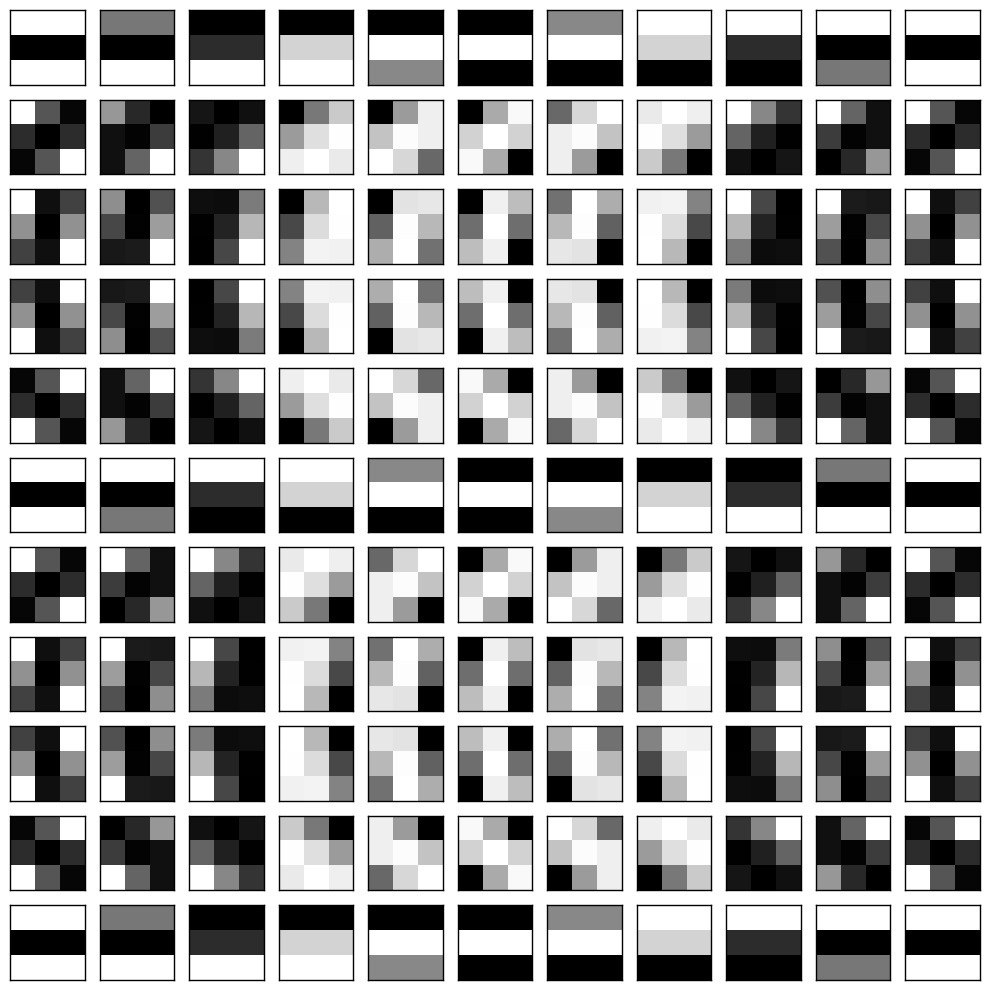

In [3]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(10, 10))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = 2 * torch.pi * i / n
        theta_2 = 2 * torch.pi * j / n
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        #filter_img = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
        axes[i, j].imshow(filter_img, cmap='gray', extent=[-1, 1, -1, 1])
        #axes[i, j].set_title(f"$\\theta_1$={theta_1:.2f}\t$\\theta_2$={theta_2:.2f}", fontsize=6)
        # Draw black border
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

fig.tight_layout()

fig.savefig('Grid-of-filters.png', dpi=300, bbox_inches='tight', transparent=True)

These 3x3 images correspond to a point cloud $\R^9$. We calculate persistent homology of this point cloud to check that the this point cloud is a point cloud on the Klein bottle. The Klein bottle has the following homology groups:
$$
H_i(K;\Z) = 
\begin{cases}
\Z, \text{ if } i=0 \\
\Z \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

`ripser` allows us to compute the homology over the finite field. We are going to compute it over $\Z/2$ and $\Z/3$. Using the Universal Coefficients Theorem, we know that

$$
H_i(K;\Z/2) = 
\begin{cases}
\Z/2, \text{ if } i=0 \\
\Z/2 \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

But

$$
H_i(K;\Z/3) = 
\begin{cases}
\Z/3, \text{ if } i=0,1 \\
0, \text{ otherwise.}
\end{cases}
$$


In [4]:
n_angles = 250

th1s = torch.rand(n_angles) * torch.pi
th2s = torch.rand(n_angles) * 2 * torch.pi

filters = torch.stack([generate_klein_filter_matrix(th1, th2, size=3, midpoint=False).flatten() for th1, th2 in zip(th1s, th2s)]).numpy()

In [5]:
%%time

diagrams2 = ripser(filters, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(filters, coeff=3, maxdim=2)['dgms']

CPU times: user 2.38 s, sys: 109 ms, total: 2.49 s
Wall time: 2.56 s


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_42955/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_42955/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


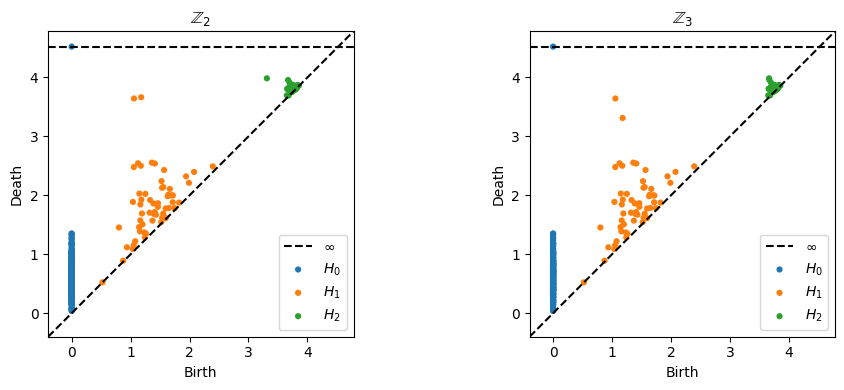

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

## Klein Circles

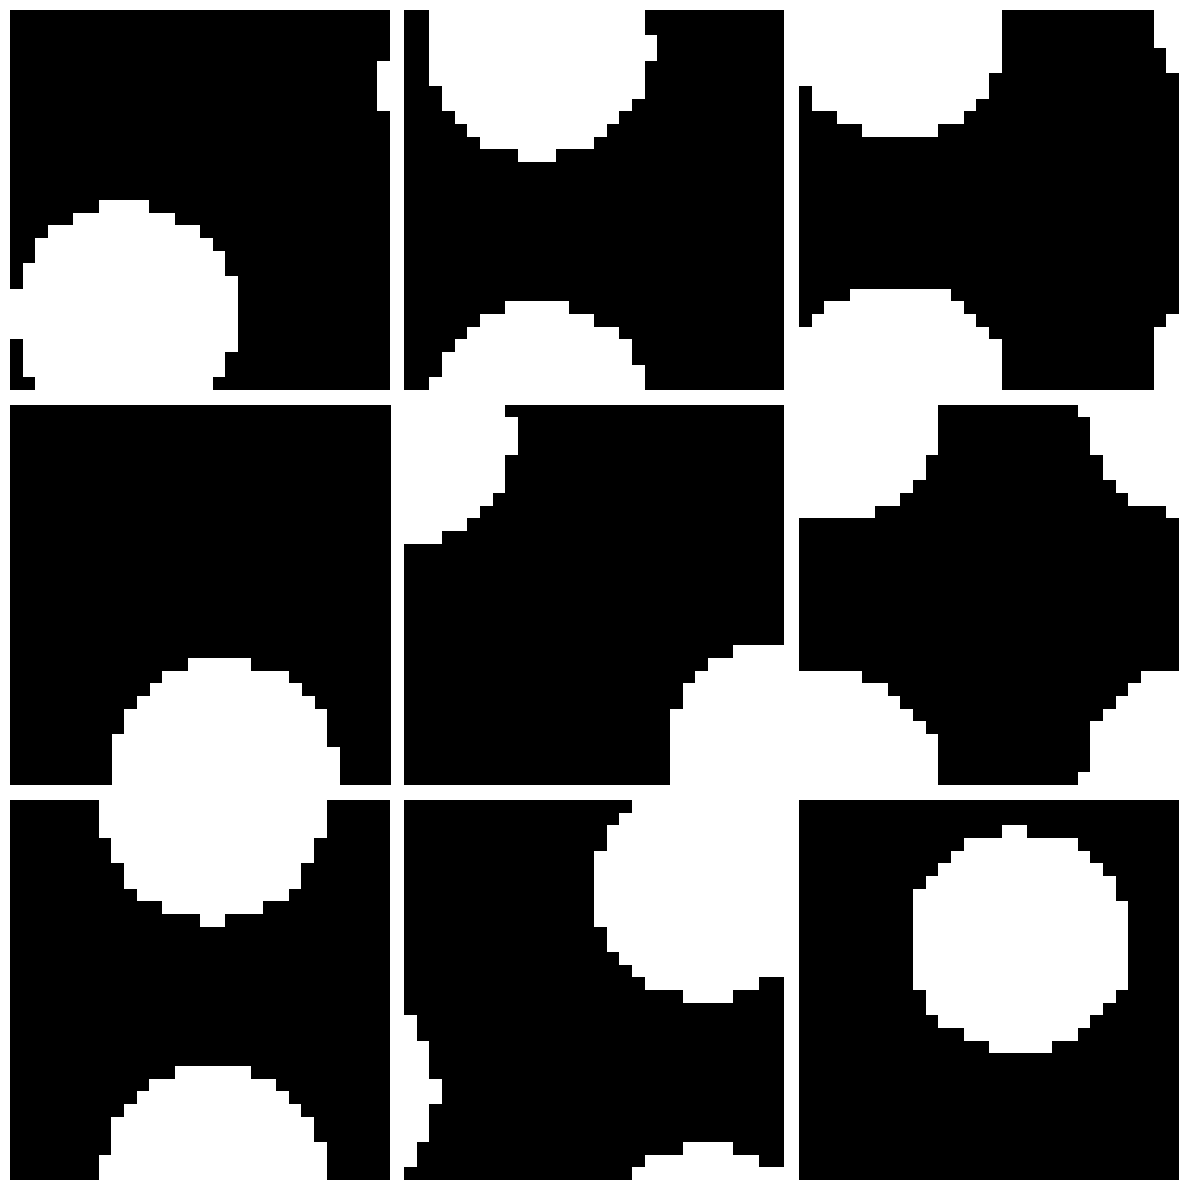

In [7]:
IMG_SIZE = 30
BATCH_SIZE = 1024
NUM_IMAGES = 100_000

datamodule = CirclesDatamodule(num_images=NUM_IMAGES, image_linear_pixel_size=IMG_SIZE, batch_size=BATCH_SIZE)
datamodule.setup()

batch = next(iter(datamodule.train_dataloader()))
images = batch[0] if isinstance(batch, (list, tuple)) else batch
indices = torch.randperm(images.size(0))[:9]
sampled_images = images[indices]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, img in zip(axes.flatten(), sampled_images):
    ax.imshow(img.reshape(IMG_SIZE,IMG_SIZE).squeeze(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Persistent homology of Klein Circles

In [8]:
batch = next(iter(datamodule.val_dataloader()))
images = batch[0] if isinstance(batch, (list, tuple)) else batch
idx = torch.randperm(images.size(0))[:500]
sampled_images = images[idx]

In [9]:
%%time

diagrams2 = ripser(sampled_images, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(sampled_images, coeff=3, maxdim=2)['dgms']

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


CPU times: user 9.41 s, sys: 267 ms, total: 9.67 s
Wall time: 9.7 s


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_42955/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_42955/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


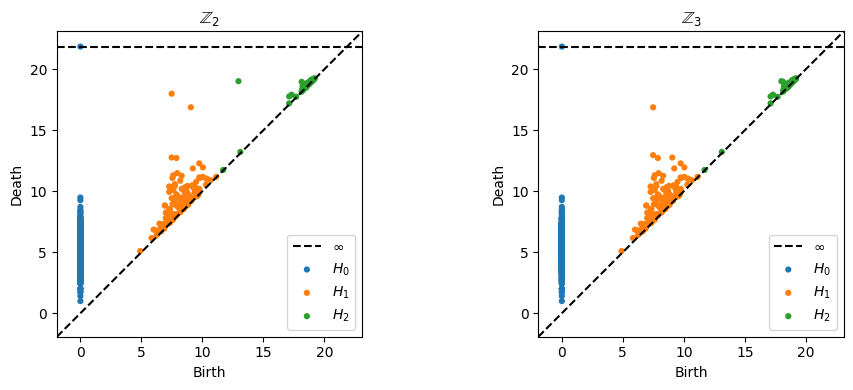

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Training the model

In [11]:
vae_model = SimpleVAE(input_dim=IMG_SIZE**2, hidden_dims=[1024, 512, 128, 32])
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=BATCH_SIZE, lr=1e-3, kl_weight=1e-2, sigma2=0.1)

In [12]:
trainer = Trainer(accelerator="cpu", max_epochs=35, enable_progress_bar=True)
trainer.fit(klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 3.0 M  | train
--------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.142    Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Epoch 34: 100%|██████████| 79/79 [00:04<00:00, 17.21it/s, v_num=176, train_loss=0.151, recon_loss=0.0805, kl_div=7.040, lr=0.000843]

`Trainer.fit` stopped: `max_epochs=35` reached.


Epoch 34: 100%|██████████| 79/79 [00:04<00:00, 17.02it/s, v_num=176, train_loss=0.151, recon_loss=0.0805, kl_div=7.040, lr=0.000843]


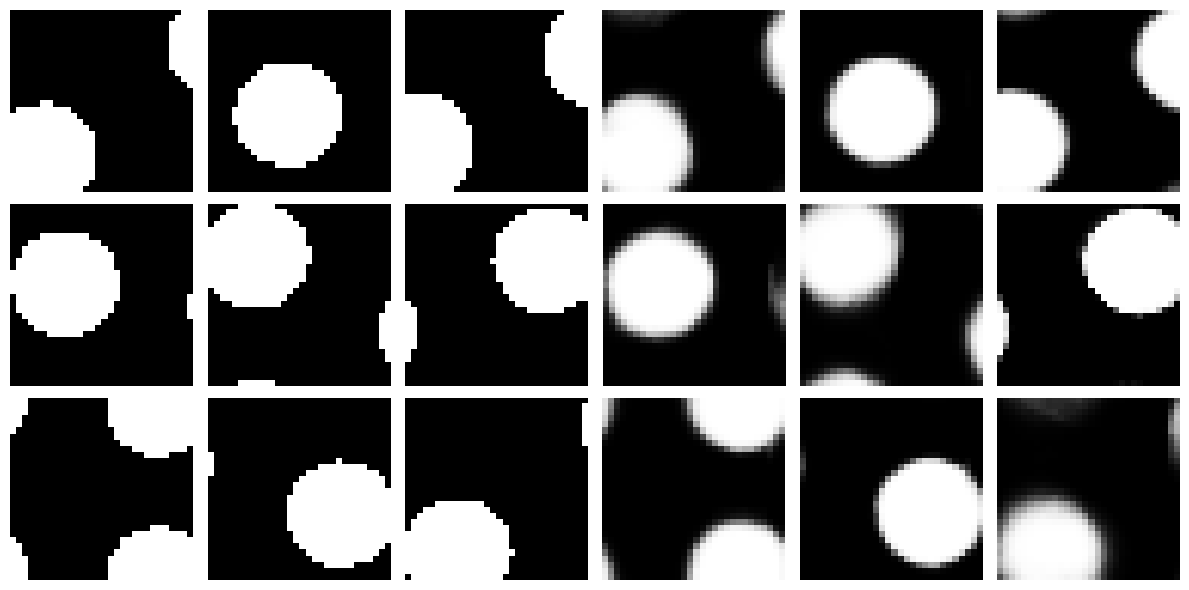

In [13]:
# get a batch from the validation set
val_loader = datamodule.val_dataloader()
val_batch = next(iter(val_loader))
images_val = val_batch[0] if isinstance(val_batch, (list, tuple)) else val_batch

# pick 9 random validation images
idx = torch.randperm(images_val.size(0))[:9]
orig = images_val[idx]

# run through VAE
klein_vae_module.eval()
with torch.no_grad():
    recon, _, _ = klein_vae_module(orig)

# plot originals and reconstructions side by side in a 3×6 grid
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for k in range(9):
    r = k // 3
    c = k % 3
    axes[r, c].imshow(orig[k].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[r, c].axis('off')
    axes[r, c+3].imshow(recon[k].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[r, c+3].axis('off')

plt.tight_layout()
plt.show()

### Persistent homology of reconstructions

In [14]:
sampled_reconstructions,_,_ = klein_vae_module(sampled_images)
sampled_reconstructions = sampled_reconstructions.detach().numpy()

In [15]:
%%time

diagrams2 = ripser(sampled_reconstructions, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(sampled_reconstructions, coeff=3, maxdim=2)['dgms']

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


CPU times: user 6.84 s, sys: 232 ms, total: 7.07 s
Wall time: 7.12 s


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_42955/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_42955/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


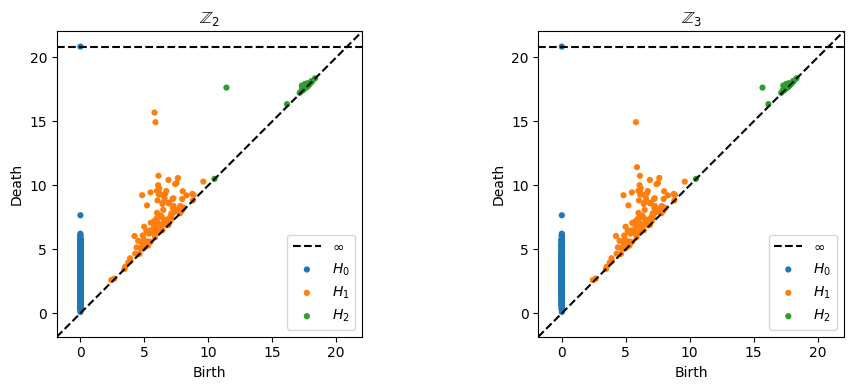

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()